# 05 — Ridge Regression

## Objective

This notebook develops a Ridge Regression model for used-car price prediction.

The same train-test split, feature-engineering steps, preprocessing pipeline, and log-transformed target from the Linear Regression notebook will be used for a fair model comparison.

The main objectives are to:

- select the best Ridge `alpha` using cross-validation on the training data;
- reduce coefficient instability caused by multicollinearity;
- evaluate Ridge Regression using MAE, RMSE, and R²;
- compare Ridge Regression with Log-Target Linear Regression;
- analyze coefficient shrinkage and model stability.

## 1. Import Required Libraries



In [30]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Validate the Dataset

The original used-car dataset is loaded from the `data/raw/` directory.

Before starting preprocessing or model training, the dataset path, shape, required target column, duplicate records, and basic target validity will be checked. This helps detect file or data problems at the beginning of the notebook.

In [2]:
data_path = "../data/raw/car_price_data.csv"

df = pd.read_csv(data_path)

assert "Price" in df.columns, "Price column not found."

print("Dataset shape:", df.shape)
print("Duplicate records:", df.duplicated().sum())
print("Missing Price values:", df["Price"].isna().sum())
print("Non-positive Price values:", (df["Price"] <= 0).sum())

df.head()

Dataset shape: (2059, 20)
Duplicate records: 0
Missing Price values: 0
Non-positive Price values: 0


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


### Initial Validation Observations

- The dataset contains 2,059 observations and 20 original columns.
- No duplicate records were found.
- The target variable, `Price`, contains no missing values.
- No zero or negative target values were identified.
- Therefore, the dataset can safely proceed to train-test splitting and log transformation.

## 3. Create the Train-Test Split

The predictor variables and target variable are separated before preprocessing.

The dataset is divided into 80% training data and 20% test data using `random_state=42`. The same split used in the Linear Regression notebook is retained to ensure a fair model comparison.

All feature engineering and preprocessing steps will be fitted using the training data only to prevent data leakage.

In [3]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1647, 19)
X_test shape: (412, 19)
y_train shape: (1647,)
y_test shape: (412,)


## 4. Apply Log Transformation to the Target

The `Price` target is strongly right-skewed. Therefore, `log1p` transformation is applied separately to the training and test targets.

The Ridge model will be trained using the log-transformed training target. Its predictions will later be converted back to the original Price scale using `expm1` before calculating MAE, RMSE, and R².

This transformation previously reduced the training-target skewness from approximately 4.45 to 0.46 and improved Linear Regression performance.

In [4]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original training Price skewness:", round(y_train.skew(), 2))
print("Log-transformed training Price skewness:", round(y_train_log.skew(), 2))

Original training Price skewness: 4.45
Log-transformed training Price skewness: 0.46


## 5. Perform Feature Engineering

The same feature-engineering approach used in the preprocessing and Linear Regression notebooks is retained for consistency.

The following numerical features will be created:

- `Vehicle_Age` from the original `Year` column;
- `Engine_CC` from `Engine`;
- `Power_BHP` and `Power_RPM` from `Max Power`;
- `Torque_NM` and `Torque_RPM_Clean` from `Max Torque`.

After extracting useful numerical information, the original text-based technical columns will be removed. Feature engineering will be applied separately to the training and test data after the split.

In [5]:
def extract_number(column):
    return pd.to_numeric(
        column.astype("string").str.extract(r"(\d+\.?\d*)")[0],
        errors="coerce"
    )


def extract_rpm(column):
    cleaned_column = column.astype("string").str.replace(",", "", regex=False)

    return pd.to_numeric(
        cleaned_column.str.extract(r"(?:@|at)\s*(\d+\.?\d*)")[0],
        errors="coerce"
    )


def engineer_features(data):
    data = data.copy()

    data["Vehicle_Age"] = 2022 - data["Year"]
    data["Engine_CC"] = extract_number(data["Engine"])
    data["Power_BHP"] = extract_number(data["Max Power"])
    data["Power_RPM"] = extract_rpm(data["Max Power"])
    data["Torque_NM"] = extract_number(data["Max Torque"])
    data["Torque_RPM_Clean"] = extract_rpm(data["Max Torque"])

    kgm_rows = data["Max Torque"].astype("string").str.contains(
        "kgm", case=False, na=False
    )
    data.loc[kgm_rows, "Torque_NM"] *= 9.80665

    data = data.drop(
        columns=["Year", "Engine", "Max Power", "Max Torque"]
    )

    return data


X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)

print("Training shape after feature engineering:", X_train_fe.shape)
print("Test shape after feature engineering:", X_test_fe.shape)

Training shape after feature engineering: (1647, 21)
Test shape after feature engineering: (412, 21)


## 6. Build the Preprocessing Pipeline

Numerical and categorical features are identified using the feature-engineered training data.

The preprocessing pipeline will:

- replace missing numerical values with the training median;
- add indicators for numerical missing values;
- standardize numerical features;
- replace missing categorical values with `Missing`;
- group infrequent categories using `min_frequency=5`;
- convert categorical features using one-hot encoding;
- ignore unseen test categories;
- drop the first category to avoid redundant dummy variables.

The preprocessor will remain inside the Ridge model pipeline. Therefore, it will learn all imputation, scaling, and encoding rules from training data only.

In [6]:
numerical_features = X_train_fe.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train_fe.select_dtypes(
    exclude=np.number
).columns.tolist()

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        min_frequency=5
    ))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total input features:", len(numerical_features) + len(categorical_features))

Numerical features: 12
Categorical features: 9
Total input features: 21


## 7. Train a Basic Ridge Regression Model

Ridge Regression extends Linear Regression by adding an L2 penalty to the loss function. This penalty shrinks large coefficients and can improve coefficient stability when predictors are strongly correlated.

The strength of regularization is controlled by `alpha`:

- `alpha = 0` behaves like ordinary Linear Regression;
- a small positive `alpha` applies weak coefficient shrinkage;
- a larger `alpha` applies stronger coefficient shrinkage.

A basic Ridge model with the default `alpha=1.0` will first be trained as an initial reference. The best `alpha` will be selected later using cross-validation on training data only.

In [7]:
basic_ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])

basic_ridge_model.fit(X_train_fe, y_train_log)

print("Basic Ridge model fitted successfully.")

Basic Ridge model fitted successfully.


### 7.1 Generate Basic Ridge Predictions
The fitted basic Ridge model will predict the test observations on the log-transformed target scale.

The log predictions will then be converted back to the original Price scale using `expm1`. All final evaluation metrics will be calculated using original car prices.

In [13]:
basic_log_predictions = basic_ridge_model.predict(X_test_fe)

basic_price_predictions = np.expm1(basic_log_predictions)

print("Predictions generated:", len(basic_price_predictions))
print("Negative predictions:", (basic_price_predictions < 0).sum())
print("First five predicted prices:", basic_price_predictions[:5].round(2))

Predictions generated: 412
Negative predictions: 0
First five predicted prices: [4397755.45  728737.93  586977.01 1155125.48  597813.25]


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Basic Ridge Prediction Observations

- Predictions were generated for all 412 test observations.
- The model produced no negative Price predictions.
- The warning indicates that some test observations contained unseen categories in `Make`, `Model`, `Fuel Type`, and `Location`.
- Because `handle_unknown="ignore"` was used, these unseen categories were encoded as all zeros and the prediction process continued.
- Although the pipeline handled them successfully, unseen categories may reduce prediction accuracy for the affected observations.

### 7.2 Evaluate the Basic Ridge Model

The basic Ridge predictions are evaluated on the original Price scale using:

- **MAE:** the average absolute difference between actual and predicted prices;
- **RMSE:** an error measure that gives greater weight to large prediction errors;
- **R²:** the proportion of Price variation explained by the model.

Lower MAE and RMSE values indicate better performance, while a higher R² value indicates a better model fit.

This evaluation provides an initial reference before selecting the best `alpha` through cross-validation.

In [14]:
basic_ridge_mae = mean_absolute_error(
    y_test,
    basic_price_predictions
)

basic_ridge_rmse = np.sqrt(
    mean_squared_error(y_test, basic_price_predictions)
)

basic_ridge_r2 = r2_score(
    y_test,
    basic_price_predictions
)

print("Basic Ridge Regression Results")
print("MAE:", round(basic_ridge_mae, 2))
print("RMSE:", round(basic_ridge_rmse, 2))
print("R²:", round(basic_ridge_r2, 4))

Basic Ridge Regression Results
MAE: 301740.34
RMSE: 990955.15
R²: 0.8594


### Basic Ridge Evaluation Observations

- The basic Ridge model with `alpha=1.0` achieved an MAE of `301,740.34`, an RMSE of `990,955.15`, and an R² of `0.8594`.
- The model explained approximately 85.94% of the variation in test-set car prices.
- It performed slightly better than Log-Target Linear Regression, which achieved an MAE of approximately `302,345`, an RMSE of approximately `996,774`, and an R² of approximately `0.8578`.
- This improvement suggests that L2 regularization may reduce coefficient instability caused by multicollinearity.
- However, `alpha=1.0` is only the default value and cannot be considered optimal before cross-validation.

## 8. Select the Best Alpha Using Cross-Validation

The default `alpha=1.0` may not provide the best regularization strength. Therefore, several alpha values will be tested from very weak to very strong regularization.

Five-fold cross-validation will be performed using the training data only. In every fold, the complete preprocessing and Ridge pipeline will be fitted again to prevent data leakage.

The alpha with the lowest mean validation Log RMSE will be selected. The test set will remain completely unused during hyperparameter selection.

### 8.1 Test Alpha Values Using Cross-Validation

A sensible range of `alpha` values is tested using five-fold cross-validation.

The complete preprocessing and Ridge pipeline is fitted separately within every training fold to prevent data leakage. The test set is not used during alpha selection.

The alpha with the lowest mean validation Log RMSE will be selected. The search will only identify the best alpha; the final Ridge model will be fitted separately afterward.

In [15]:
alpha_values = [
    0.001, 0.01, 0.1, 0.5, 1,
    2, 5, 10, 50, 100, 500, 1000
]

ridge_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge())
])

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_search = GridSearchCV(
    estimator=ridge_cv_pipeline,
    param_grid={"ridge__alpha": alpha_values},
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

ridge_search.fit(X_train_fe, y_train_log)

print("Alpha values tested:", alpha_values)
print("Best alpha:", ridge_search.best_params_["ridge__alpha"])
print(
    "Best mean validation Log RMSE:",
    round(-ridge_search.best_score_, 4)
)

Alpha values tested: [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000]
Best alpha: 0.5
Best mean validation Log RMSE: 0.2752


### Alpha Search Observations

- Twelve alpha values ranging from `0.001` to `1000` were tested using five-fold cross-validation.
- `alpha=0.5` achieved the lowest mean validation Log RMSE of `0.2752`.
- The selected value represents relatively mild L2 regularization.
- The best alpha was selected using training data only; the test set remained unused.
- Because `0.5` is not located at the boundary of the tested range, the alpha search range appears reasonable.

### 8.2 Organize the Cross-Validation Results

The complete cross-validation results are organized into a DataFrame for clear comparison.

The table displays the mean training Log RMSE, mean validation Log RMSE, validation-score standard deviation, and rank for each alpha value.

The results are sorted by alpha, while Rank 1 identifies the best-performing value. Lower training and validation Log RMSE values indicate better performance.

In [16]:
ridge_cv_results = pd.DataFrame({
    "Alpha": ridge_search.cv_results_["param_ridge__alpha"],
    "Mean Train Log RMSE": -ridge_search.cv_results_["mean_train_score"],
    "Mean Validation Log RMSE": -ridge_search.cv_results_["mean_test_score"],
    "Validation RMSE Standard Deviation": ridge_search.cv_results_["std_test_score"],
    "Rank": ridge_search.cv_results_["rank_test_score"]
})

ridge_cv_results["Alpha"] = pd.to_numeric(
    ridge_cv_results["Alpha"]
)

ridge_cv_results = ridge_cv_results.sort_values(
    "Alpha"
).reset_index(drop=True)

ridge_cv_results.round(4)

,Alpha,Mean Train Log RMSE,Mean Validation Log RMSE,Validation RMSE Standard Deviation,Rank
0,0.001,0.2249,0.2764,0.0252,5
1,0.010,0.2249,0.2760,0.0253,4
2,0.100,0.2249,0.2758,0.0258,3
3,0.500,0.2259,0.2752,0.0258,1
4,1.000,0.2277,0.2756,0.0253,2
5,2.000,0.2313,0.2769,0.0247,6
6,5.000,0.2398,0.2806,0.0241,7
7,10.000,0.2489,0.2847,0.0239,8
8,50.000,0.2758,0.3005,0.0255,9
9,100.000,0.2889,0.3105,0.0279,10


### Cross-Validation Results Observations

- `alpha=0.5` achieved the lowest mean validation Log RMSE of `0.2752` and received Rank 1.
- `alpha=0.1` and `alpha=1.0` produced very similar validation results, indicating a relatively stable best-performing region.
- Training error increased as alpha increased because stronger regularization restricted the coefficient values.
- Alpha values of `50` and above substantially increased both training and validation errors.
- This pattern indicates that excessive regularization caused underfitting.
- Based only on training-data cross-validation, `alpha=0.5` was selected for the final Ridge model.

## 9. Fit the Best Ridge Regression Model

Five-fold cross-validation selected `alpha=0.5` as the best regularization strength.

A new Ridge pipeline will now be created using this alpha value. The complete preprocessing and Ridge model will be fitted using the full training dataset only.

The final model fitting, prediction, and evaluation steps will remain in separate cells for clarity.

In [17]:
best_alpha = ridge_search.best_params_["ridge__alpha"]

best_ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=best_alpha))
])

best_ridge_model.fit(X_train_fe, y_train_log)

print("Best Ridge model fitted successfully.")
print("Selected alpha:", best_alpha)

Best Ridge model fitted successfully.
Selected alpha: 0.5


## 10. Generate Test-Set Predictions

The fitted best Ridge model will predict car prices for the test dataset.

Predictions will first be produced on the log-transformed target scale and then converted back to the original Price scale using `expm1`.

The test set is used only for final prediction and evaluation, not for model fitting or alpha selection.

In [18]:
best_log_predictions = best_ridge_model.predict(X_test_fe)

best_price_predictions = np.expm1(best_log_predictions)

print("Predictions generated:", len(best_price_predictions))
print("Negative predictions:", (best_price_predictions < 0).sum())
print("First five predicted prices:", best_price_predictions[:5].round(2))

Predictions generated: 412
Negative predictions: 0
First five predicted prices: [4392553.31  725674.1   583320.88 1159356.07  604074.5 ]


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Best Ridge Prediction Observations

- The best Ridge model generated predictions for all 412 test observations.
- No negative Price predictions were produced.
- The predictions differ slightly from the basic Ridge model because the regularization strength changed from `alpha=1.0` to `alpha=0.5`.


## 11. Evaluate the Best Ridge Regression Model

The best Ridge model is evaluated on the untouched test set using predictions converted back to the original Price scale.

The same evaluation metrics used for Linear Regression and Basic Ridge are retained:

- **MAE** measures the average absolute prediction error;
- **RMSE** gives greater weight to large prediction errors;
- **R²** measures the proportion of Price variation explained by the model.

Using the same test split and metrics ensures a fair model comparison.

In [19]:
best_ridge_mae = mean_absolute_error(
    y_test,
    best_price_predictions
)

best_ridge_rmse = np.sqrt(
    mean_squared_error(y_test, best_price_predictions)
)

best_ridge_r2 = r2_score(
    y_test,
    best_price_predictions
)

print("Best Ridge Regression Results")
print("Selected alpha:", best_alpha)
print("MAE:", round(best_ridge_mae, 2))
print("RMSE:", round(best_ridge_rmse, 2))
print("R²:", round(best_ridge_r2, 4))

Best Ridge Regression Results
Selected alpha: 0.5
MAE: 301182.74
RMSE: 999198.6
R²: 0.8571


### Best Ridge Evaluation Observations

- The final Ridge model with `alpha=0.5` achieved an MAE of `301,182.74`, an RMSE of `999,198.60`, and an R² of `0.8571`.
- Compared with Basic Ridge (`alpha=1.0`), the final model achieved a slightly lower MAE but a higher RMSE and slightly lower R².
- The lower MAE indicates a small improvement in average prediction error, while the higher RMSE suggests that some large prediction errors increased.
- Compared with Log-Target Linear Regression, Ridge achieved a slightly lower MAE but slightly worse RMSE and R².
- Cross-validation selected `alpha=0.5` using validation Log RMSE, whereas final test metrics were calculated on the original Price scale. Therefore, the selected alpha is not guaranteed to outperform every other alpha on all test metrics.
- The test set was not used to change the selected alpha, preserving an unbiased evaluation workflow.

## 12. Compare Ridge Regression with Linear Regression

The final Ridge model will be compared with Log-Target Linear Regression and Basic Ridge Regression using the same test dataset and evaluation metrics.

The exact Linear Regression results will be loaded from the previously saved `linear_model_comparison.csv` file. This avoids manually entering approximate values and maintains consistency between notebooks.

The comparison will focus on MAE, RMSE, and R². Ridge coefficient stability will be analyzed separately in the next sections.

In [20]:
linear_results = pd.read_csv(
    "../results/linear_model_comparison.csv"
)

print("Columns:", linear_results.columns.tolist())

linear_results

Columns: ['Model', 'MAE', 'RMSE', 'R2', 'Negative Predictions']


,Model,MAE,RMSE,R2,Negative Predictions
0,Dummy Baseline,1.454531e+06,2.643347e+06,-0.000144,0
1,Linear Regression,6.586477e+05,1.414702e+06,0.713527,71
2,Log-Target Linear Regression,3.023453e+05,9.967745e+05,0.857784,0


### 12.1 Build the Model Comparison Table

The exact Log-Target Linear Regression results are combined with the Basic Ridge and Best Ridge results.

The comparison table includes each model's alpha value, MAE, RMSE, R², and number of negative predictions.

This table will show whether Ridge provides a meaningful predictive improvement over Log-Target Linear Regression.

In [21]:
log_linear_result = linear_results[
    linear_results["Model"] == "Log-Target Linear Regression"
].iloc[0]

ridge_model_comparison = pd.DataFrame({
    "Model": [
        "Log-Target Linear Regression",
        "Basic Ridge Regression",
        "Best Ridge Regression"
    ],
    "Alpha": [
        np.nan,
        1.0,
        best_alpha
    ],
    "MAE": [
        log_linear_result["MAE"],
        basic_ridge_mae,
        best_ridge_mae
    ],
    "RMSE": [
        log_linear_result["RMSE"],
        basic_ridge_rmse,
        best_ridge_rmse
    ],
    "R2": [
        log_linear_result["R2"],
        basic_ridge_r2,
        best_ridge_r2
    ],
    "Negative Predictions": [
        int(log_linear_result["Negative Predictions"]),
        int((basic_price_predictions < 0).sum()),
        int((best_price_predictions < 0).sum())
    ]
})

ridge_model_comparison.round({
    "Alpha": 2,
    "MAE": 2,
    "RMSE": 2,
    "R2": 4
})

,Model,Alpha,MAE,RMSE,R2,Negative Predictions
0,Log-Target Linear Regression,NaN,302345.26,996774.47,0.8578,0
1,Basic Ridge Regression,1.0,301740.34,990955.15,0.8594,0
2,Best Ridge Regression,0.5,301182.74,999198.60,0.8571,0


### Model Comparison Observations

- The CV-selected Ridge model (`alpha=0.5`) achieved the lowest MAE of `301,182.74`.
- Basic Ridge (`alpha=1.0`) achieved the lowest RMSE of `990,955.15` and the highest R² of `0.8594`.
- Log-Target Linear Regression remained highly competitive, with only small performance differences from both Ridge models.
- No single model achieved the best result across all three evaluation metrics.
- All three models produced zero negative Price predictions.
- The `NaN` alpha value for Linear Regression indicates that Ridge regularization does not apply to that model.
- In this project, Ridge provides only a small predictive change. Its more important potential benefit is improved coefficient stability under multicollinearity, which will be examined next.

## 13. Analyze Ridge Regression Coefficients

The coefficients of the CV-selected Ridge model are extracted and matched with their processed feature names.

Because the target was log-transformed, each coefficient represents a change on the Log Price scale while other features remain constant.

Numerical features were standardized, which makes their coefficient magnitudes more comparable. Categorical coefficients represent differences from their dropped reference categories.

Ridge shrinks coefficients toward zero but does not normally force them to become exactly zero.

In [22]:
feature_names = best_ridge_model.named_steps[
    "preprocessor"
].get_feature_names_out()

ridge_coefficients = best_ridge_model.named_steps[
    "ridge"
].coef_

ridge_coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Ridge Coefficient": ridge_coefficients
})

ridge_coefficient_table["Absolute Ridge Coefficient"] = (
    ridge_coefficient_table["Ridge Coefficient"].abs()
)

ridge_coefficient_table = ridge_coefficient_table.sort_values(
    "Absolute Ridge Coefficient",
    ascending=False
).reset_index(drop=True)

print("Total coefficients:", len(ridge_coefficient_table))
print(
    "Exactly zero coefficients:",
    (ridge_coefficient_table["Ridge Coefficient"] == 0).sum()
)
print(
    "Ridge intercept:",
    round(best_ridge_model.named_steps["ridge"].intercept_, 4)
)

ridge_coefficient_table.head(15).round(4)

Total coefficients: 160
Exactly zero coefficients: 0
Ridge intercept: 14.2145


,Feature,Ridge Coefficient,Absolute Ridge Coefficient
0,cat__Make_Datsun,-0.8260,0.8260
1,cat__Make_Chevrolet,-0.7220,0.7220
2,cat__Make_Tata,-0.7121,0.7121
3,cat__Make_Renault,-0.6851,0.6851
4,cat__Make_Nissan,-0.6775,0.6775
5,cat__Make_MG,-0.5795,0.5795
6,cat__Owner_infrequent_sklearn,-0.5514,0.5514
7,cat__Make_Mahindra,-0.5418,0.5418
8,cat__Make_Maruti Suzuki,-0.5329,0.5329
9,cat__Make_Volkswagen,-0.5320,0.5320


### Ridge Coefficient Observations

- The final processed dataset contains 160 Ridge coefficients.
- None of the coefficients became exactly zero, which is expected because Ridge shrinks coefficients but normally retains all features.
- The largest absolute coefficients mainly belong to vehicle `Make` categories.
- `Make_Datsun` has the strongest negative coefficient among the displayed features, while `Make_MINI` has a strong positive coefficient.
- All categorical coefficients are interpreted relative to their dropped reference categories.
- The grouped infrequent `Owner` category has a strong negative coefficient, but it should be interpreted cautiously because it combines several rare categories.
- Coefficients are measured on the Log Price scale and show associations, not causal effects.
- Coefficient magnitudes across standardized numerical features and binary categorical features are not perfectly comparable.

## 14. Compare Linear and Ridge Coefficients

Ridge Regression is designed to reduce coefficient magnitude and improve stability when predictors are correlated.

The saved Log-Target Linear Regression coefficients will be loaded and matched with the final Ridge coefficients using processed feature names.

Both coefficient sets must come from the same preprocessing structure and log-transformed target for a valid comparison. The analysis will measure how much Ridge shrinks each coefficient toward zero.

In [23]:
linear_coefficients = pd.read_csv(
    "../results/linear_regression_coefficients.csv"
)

print("Shape:", linear_coefficients.shape)
print("Columns:", linear_coefficients.columns.tolist())

linear_coefficients.head()

Shape: (160, 3)
Columns: ['Feature', 'Coefficient', 'Absolute Coefficient']


,Feature,Coefficient,Absolute Coefficient
0,numerical__Kilometer,-0.028511,0.028511
1,numerical__Length,0.224586,0.224586
2,numerical__Width,0.020213,0.020213
3,numerical__Height,0.097535,0.097535
4,numerical__Seating Capacity,-0.045635,0.045635


### 14.1 Match Linear and Ridge Coefficients

The Linear and Ridge coefficient files contain the same number of processed features, but their transformer prefixes are different.

Linear Regression uses `numerical__` and `categorical__`, while Ridge uses `num__` and `cat__`.

These technical prefixes will be removed to create consistent feature names. The two coefficient tables will then be merged, and the number of matched features will be verified before calculating coefficient shrinkage.

In [26]:
linear_for_comparison = linear_coefficients[
    ["Feature", "Coefficient"]
].copy()

linear_for_comparison["Feature"] = (
    linear_for_comparison["Feature"]
    .str.replace("numerical__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("Vehicle Age", "Vehicle_Age", regex=False)
)

linear_for_comparison = linear_for_comparison.rename(
    columns={"Coefficient": "Linear Coefficient"}
)

ridge_for_comparison = ridge_coefficient_table[
    ["Feature", "Ridge Coefficient"]
].copy()

ridge_for_comparison["Feature"] = (
    ridge_for_comparison["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coefficient_comparison = linear_for_comparison.merge(
    ridge_for_comparison,
    on="Feature",
    how="inner"
)

print("Linear features:", len(linear_for_comparison))
print("Ridge features:", len(ridge_for_comparison))
print("Matched features:", len(coefficient_comparison))

if len(coefficient_comparison) != 160:
    raise ValueError("All 160 features were not matched.")

coefficient_comparison.head()

Linear features: 160
Ridge features: 160
Matched features: 160


,Feature,Linear Coefficient,Ridge Coefficient
0,Kilometer,-0.028511,-0.029076
1,Length,0.224586,0.220482
2,Width,0.020213,0.022624
3,Height,0.097535,0.082471
4,Seating Capacity,-0.045635,-0.042465


### Feature Matching Observations

- All 160 Linear and Ridge coefficients were successfully matched.
- The earlier mismatch was caused only by `Vehicle Age` and `Vehicle_Age` naming differences.
- No feature or coefficient was removed during name standardization.
- The sample results show that Linear and Ridge coefficients are similar but not identical.
- Ridge does not guarantee that every individual coefficient will become smaller because correlated-feature effects can be redistributed.
- Overall coefficient magnitude and feature-level changes will be measured next.

### 14.2 Measure Coefficient Shrinkage

The absolute Linear and Ridge coefficient magnitudes will be compared for all 160 processed features.

A positive magnitude change indicates that Ridge moved a coefficient closer to zero. A negative change indicates that an individual coefficient became larger because effects may be redistributed among correlated predictors.

The overall L2 norm of each coefficient vector will also be calculated. A lower Ridge L2 norm provides direct evidence of overall coefficient shrinkage.

In [27]:
coefficient_comparison["Absolute Linear Coefficient"] = (
    coefficient_comparison["Linear Coefficient"].abs()
)

coefficient_comparison["Absolute Ridge Coefficient"] = (
    coefficient_comparison["Ridge Coefficient"].abs()
)

coefficient_comparison["Magnitude Change"] = (
    coefficient_comparison["Absolute Linear Coefficient"]
    - coefficient_comparison["Absolute Ridge Coefficient"]
)

linear_l2_norm = np.linalg.norm(
    coefficient_comparison["Linear Coefficient"]
)

ridge_l2_norm = np.linalg.norm(
    coefficient_comparison["Ridge Coefficient"]
)

l2_reduction_percent = (
    (linear_l2_norm - ridge_l2_norm)
    / linear_l2_norm
    * 100
)

shrunk_coefficients = (
    coefficient_comparison["Magnitude Change"] > 0
).sum()

increased_coefficients = (
    coefficient_comparison["Magnitude Change"] < 0
).sum()

coefficient_shrinkage_table = coefficient_comparison.sort_values(
    "Magnitude Change",
    ascending=False
).reset_index(drop=True)

print("Linear coefficient L2 norm:", round(linear_l2_norm, 4))
print("Ridge coefficient L2 norm:", round(ridge_l2_norm, 4))
print("L2 norm reduction:", round(l2_reduction_percent, 2), "%")
print("Coefficients moved closer to zero:", shrunk_coefficients)
print("Coefficients increased in magnitude:", increased_coefficients)

coefficient_shrinkage_table.head(15).round(4)

Linear coefficient L2 norm: 3.2472
Ridge coefficient L2 norm: 2.7547
L2 norm reduction: 15.17 %
Coefficients moved closer to zero: 115
Coefficients increased in magnitude: 45


,Feature,Linear Coefficient,Ridge Coefficient,Absolute Linear Coefficient,Absolute Ridge Coefficient,Magnitude Change
0,Make_Datsun,-0.9942,-0.8260,0.9942,0.8260,0.1683
1,Make_Chevrolet,-0.8855,-0.7220,0.8855,0.7220,0.1636
2,Make_Nissan,-0.8089,-0.6775,0.8089,0.6775,0.1314
3,Make_MG,-0.7049,-0.5795,0.7049,0.5795,0.1254
4,Make_Renault,-0.8010,-0.6851,0.8010,0.6851,0.1159
5,Make_Tata,-0.8226,-0.7121,0.8226,0.7121,0.1105
6,Make_Kia,-0.5094,-0.4014,0.5094,0.4014,0.1080
7,Color_infrequent_sklearn,0.2383,0.1328,0.2383,0.1328,0.1055
8,Owner_infrequent_sklearn,-0.6518,-0.5514,0.6518,0.5514,0.1004
9,Color_Orange,0.1866,0.0866,0.1866,0.0866,0.1000


### Coefficient Shrinkage Observations

- The Linear coefficient L2 norm decreased from `3.2472` to `2.7547` under Ridge Regression.
- This represents an overall L2 norm reduction of `15.17%`, confirming that Ridge reduced total coefficient magnitude.
- A total of 115 out of 160 coefficients moved closer to zero.
- The remaining 45 coefficients increased in magnitude because Ridge can redistribute effects among correlated predictors.
- The largest reductions mainly occurred in vehicle `Make` and rare categorical features.
- Shrinking large categorical coefficients can reduce sensitivity to sparse or highly correlated feature patterns.
- These results provide evidence of coefficient shrinkage, but coefficient stability across different samples requires separate analysis.

## 15. Visualize Coefficient Shrinkage

The features with the largest reductions in absolute coefficient magnitude will be displayed in a horizontal bar chart.

For each selected feature, the absolute Linear coefficient will be compared with the absolute Ridge coefficient.

A shorter Ridge bar indicates that regularization moved the coefficient closer to zero. The figure will be saved in the `results/figures/` directory.

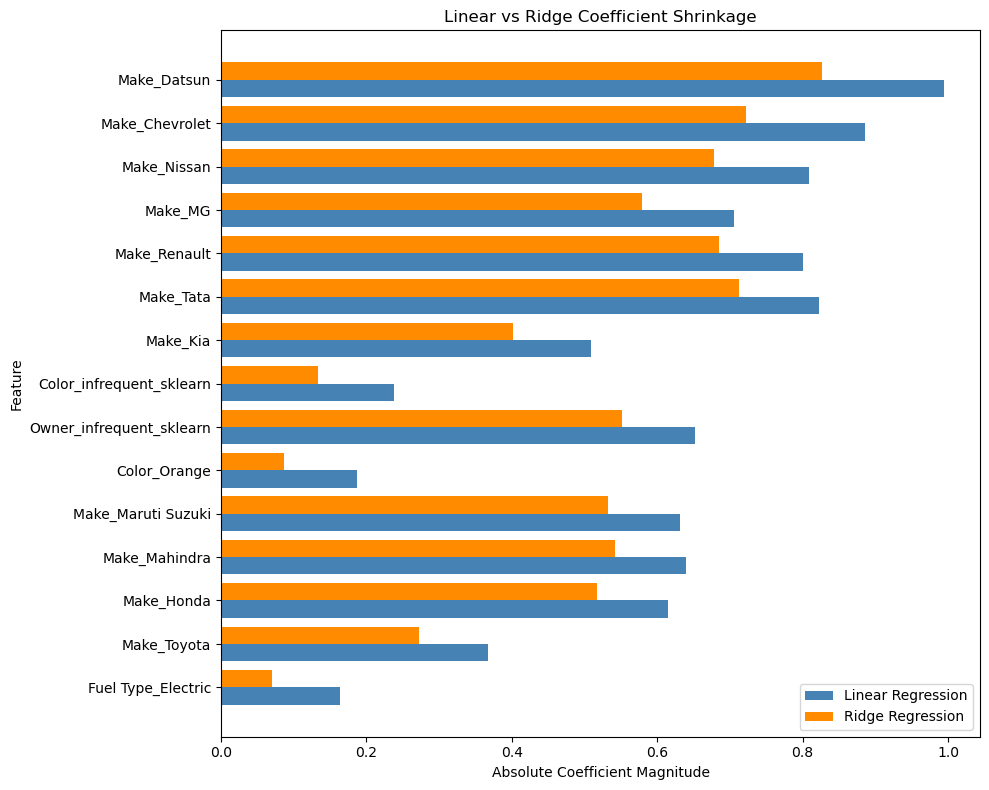

Figure saved to: ..\results\figures\ridge_coefficient_shrinkage.png


In [28]:
top_shrinkage = coefficient_shrinkage_table.head(15).sort_values(
    "Magnitude Change",
    ascending=True
)

y_positions = np.arange(len(top_shrinkage))

plt.figure(figsize=(10, 8))

plt.barh(
    y_positions - 0.2,
    top_shrinkage["Absolute Linear Coefficient"],
    height=0.4,
    label="Linear Regression",
    color="steelblue"
)

plt.barh(
    y_positions + 0.2,
    top_shrinkage["Absolute Ridge Coefficient"],
    height=0.4,
    label="Ridge Regression",
    color="darkorange"
)

plt.yticks(
    y_positions,
    top_shrinkage["Feature"]
)

plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Linear vs Ridge Coefficient Shrinkage")
plt.legend()
plt.tight_layout()

figures_path = Path("../results/figures")
figures_path.mkdir(parents=True, exist_ok=True)

shrinkage_figure_path = (
    figures_path / "ridge_coefficient_shrinkage.png"
)

plt.savefig(
    shrinkage_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", shrinkage_figure_path)

### Coefficient Shrinkage Visualization Observations

- Ridge coefficients are smaller than Linear coefficients for all 15 displayed features.
- The largest visible shrinkage occurs mainly in vehicle `Make` categories.
- `Make_Datsun` has the largest coefficient magnitude in both models, but Ridge reduces it substantially.
- Rare-category features and `Fuel Type_Electric` also show noticeable shrinkage.
- This reduction indicates that Ridge makes the model less dependent on large individual coefficients.
- The graph displays absolute coefficient magnitudes, so it shows coefficient size but not positive or negative direction.
- Only the 15 features with the largest reductions are shown; it does not represent the behavior of every coefficient.

## 16. Examine Multicollinearity and Coefficient Stability

Ridge Regression does not remove correlation among predictors and does not reduce their VIF values. Instead, it adds an L2 penalty that limits large coefficients and makes their estimates less sensitive to changes in the training sample.

Coefficient stability will be examined by fitting Linear and Ridge models on five different training subsets and measuring how much each coefficient varies across the fitted models.

A fixed feature space derived from the full training data will be used so that corresponding coefficients remain directly comparable. This is a stability diagnostic, not model evaluation or hyperparameter selection. The test set remains unused.

### 16.1 Fit Linear and Ridge Models Across Training Subsets

The fitted training preprocessor will first create one consistent 160-feature design matrix.

Five shuffled training subsets will then be created using `random_state=42`. Linear Regression and Ridge Regression with `alpha=0.5` will be fitted on the same subset in every fold.

The coefficient vectors from all five fitted models will be stored for the stability comparison. This repeated fitting requires a short loop.

In [31]:

X_train_processed = best_ridge_model.named_steps[
    "preprocessor"
].transform(X_train_fe)

y_train_log_array = y_train_log.to_numpy()

stability_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

linear_fold_coefficients = []
ridge_fold_coefficients = []

for fold_train_indices, _ in stability_cv.split(X_train_processed):
    X_fold_train = X_train_processed[fold_train_indices]
    y_fold_train = y_train_log_array[fold_train_indices]

    fold_linear_model = LinearRegression()
    fold_ridge_model = Ridge(alpha=best_alpha)

    fold_linear_model.fit(X_fold_train, y_fold_train)
    fold_ridge_model.fit(X_fold_train, y_fold_train)

    linear_fold_coefficients.append(
        fold_linear_model.coef_
    )

    ridge_fold_coefficients.append(
        fold_ridge_model.coef_
    )

linear_fold_coefficients = np.array(
    linear_fold_coefficients
)

ridge_fold_coefficients = np.array(
    ridge_fold_coefficients
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Linear coefficient matrix:",
    linear_fold_coefficients.shape
)

print(
    "Ridge coefficient matrix:",
    ridge_fold_coefficients.shape
)

Processed training shape: (1647, 160)
Linear coefficient matrix: (5, 160)
Ridge coefficient matrix: (5, 160)


### 16.2 Measure Coefficient Stability

For each processed feature, the standard deviation of its five fitted coefficient values will be calculated separately for Linear and Ridge Regression.

A lower coefficient standard deviation indicates that the estimated feature effect changes less across training subsets and is therefore more stable.

The comparison will report:

- mean coefficient standard deviation;
- median coefficient standard deviation;
- the number of features for which Ridge is more stable;
- the percentage reduction in mean coefficient variability.

In [32]:
stability_feature_names = pd.Series(feature_names)

stability_feature_names = (
    stability_feature_names
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

linear_coefficient_sd = np.std(
    linear_fold_coefficients,
    axis=0,
    ddof=1
)

ridge_coefficient_sd = np.std(
    ridge_fold_coefficients,
    axis=0,
    ddof=1
)

coefficient_stability_table = pd.DataFrame({
    "Feature": stability_feature_names,
    "Linear Coefficient SD": linear_coefficient_sd,
    "Ridge Coefficient SD": ridge_coefficient_sd
})

coefficient_stability_table["Stability Improvement"] = (
    coefficient_stability_table["Linear Coefficient SD"]
    - coefficient_stability_table["Ridge Coefficient SD"]
)

mean_linear_sd = linear_coefficient_sd.mean()
mean_ridge_sd = ridge_coefficient_sd.mean()

median_linear_sd = np.median(linear_coefficient_sd)
median_ridge_sd = np.median(ridge_coefficient_sd)

stability_reduction_percent = (
    (mean_linear_sd - mean_ridge_sd)
    / mean_linear_sd
    * 100
)

ridge_more_stable_count = (
    ridge_coefficient_sd < linear_coefficient_sd
).sum()

coefficient_stability_table = coefficient_stability_table.sort_values(
    "Stability Improvement",
    ascending=False
).reset_index(drop=True)

print("Mean Linear coefficient SD:", round(mean_linear_sd, 4))
print("Mean Ridge coefficient SD:", round(mean_ridge_sd, 4))
print("Median Linear coefficient SD:", round(median_linear_sd, 4))
print("Median Ridge coefficient SD:", round(median_ridge_sd, 4))
print(
    "Reduction in mean coefficient variability:",
    round(stability_reduction_percent, 2),
    "%"
)
print(
    "Features more stable under Ridge:",
    ridge_more_stable_count,
    "out of 160"
)

coefficient_stability_table.head(15).round(4)

Mean Linear coefficient SD: 0.0518
Mean Ridge coefficient SD: 0.0323
Median Linear coefficient SD: 0.0464
Median Ridge coefficient SD: 0.0253
Reduction in mean coefficient variability: 37.7 %
Features more stable under Ridge: 140 out of 160


,Feature,Linear Coefficient SD,Ridge Coefficient SD,Stability Improvement
0,Model_V40 D3 R-Design,0.1381,0.0608,0.0774
1,Model_Kwid 1.0 RXT [2016-2019],0.1035,0.0340,0.0695
2,Model_Vitara Brezza VDi (O) [2016-2018],0.1019,0.0329,0.0690
3,Color_Yellow,0.2053,0.1387,0.0666
4,Model_Q3 35 TDI Premium + Sunroof,0.1063,0.0417,0.0647
5,Model_Wagon R VXI,0.0857,0.0225,0.0631
6,Model_City V,0.0830,0.0200,0.0630
7,Model_infrequent_sklearn,0.0731,0.0107,0.0623
8,Model_Vitara Brezza ZDi,0.0913,0.0291,0.0623
9,Model_Verna 1.6 CRDI SX,0.0866,0.0246,0.0620


### Coefficient Stability Observations

- The mean coefficient standard deviation decreased from `0.0518` for Linear Regression to `0.0323` for Ridge Regression.
- This represents a `37.70%` reduction in mean coefficient variability.
- The median coefficient standard deviation also decreased from `0.0464` to `0.0253`.
- Ridge produced more stable coefficients for 140 out of 160 processed features.
- The largest stability improvements mainly occurred in high-cardinality `Model` categories and rare categorical levels.
- Twenty features were not more stable under Ridge, so regularization did not improve every coefficient individually.
- Overall, the results provide empirical evidence that Ridge reduced coefficient sensitivity to changes in the training sample.
- This five-fold diagnostic measures sample-based coefficient stability; it does not represent confidence intervals or causal certainty.

### 16.3 Relate Ridge Stability to Existing VIF Results

The VIF results saved during Linear Regression analysis will be reviewed alongside the Ridge findings.

VIF measures correlation-related redundancy among predictors. Because Ridge does not change the feature data, the original VIF values remain unchanged.

The purpose of this comparison is to show that Ridge addresses the consequences of multicollinearity through coefficient shrinkage and improved stability rather than removing the underlying predictor correlations.

In [33]:
vif_results = pd.read_csv(
    "../results/linear_regression_vif.csv"
)

print("Shape:", vif_results.shape)
print("Columns:", vif_results.columns.tolist())

vif_results.head(10)

Shape: (12, 2)
Columns: ['Feature', 'VIF']


,Feature,VIF
0,Kilometer,1.148338
1,Length,5.828948
2,Width,4.269518
3,Height,2.950711
4,Seating Capacity,2.724525
5,Fuel Tank Capacity,4.530340
6,Vehicle Age,1.254846
7,Engine_CC,8.700895
8,Power_BHP,18.566756
9,Power_RPM,7.862291


### 16.4 Compare High-VIF Features with Linear and Ridge Coefficients

The numerical VIF results will be merged with the matched Linear and Ridge coefficient table.

The comparison will show whether Ridge reduced the coefficient magnitudes of highly correlated numerical predictors.

The table will be sorted from the highest to the lowest VIF. VIF values will remain unchanged because Ridge modifies coefficient estimation, not the predictor correlation structure.

In [34]:
vif_for_comparison = vif_results.copy()

vif_for_comparison["Feature"] = (
    vif_for_comparison["Feature"]
    .str.replace("Vehicle Age", "Vehicle_Age", regex=False)
)

high_vif_coefficient_comparison = vif_for_comparison.merge(
    coefficient_comparison[
        [
            "Feature",
            "Linear Coefficient",
            "Ridge Coefficient",
            "Absolute Linear Coefficient",
            "Absolute Ridge Coefficient",
            "Magnitude Change"
        ]
    ],
    on="Feature",
    how="inner"
)

high_vif_coefficient_comparison = (
    high_vif_coefficient_comparison
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("VIF features:", len(vif_for_comparison))
print(
    "Matched numerical features:",
    len(high_vif_coefficient_comparison)
)

if len(high_vif_coefficient_comparison) != 12:
    raise ValueError("All 12 VIF features were not matched.")

high_vif_coefficient_comparison.round(4)

VIF features: 12
Matched numerical features: 12


,Feature,VIF,Linear Coefficient,Ridge Coefficient,Absolute Linear Coefficient,Absolute Ridge Coefficient,Magnitude Change
0,Power_BHP,18.5668,0.3299,0.3277,0.3299,0.3277,0.0022
1,Torque_NM,17.8130,-0.1413,-0.1285,0.1413,0.1285,0.0128
2,Engine_CC,8.7009,0.0248,0.0207,0.0248,0.0207,0.0041
3,Power_RPM,7.8623,0.0018,0.0050,0.0018,0.0050,-0.0032
4,Length,5.8289,0.2246,0.2205,0.2246,0.2205,0.0041
5,Torque_RPM_Clean,4.5594,-0.0489,-0.0539,0.0489,0.0539,-0.0051
6,Fuel Tank Capacity,4.5303,0.0109,0.0198,0.0109,0.0198,-0.0089
7,Width,4.2695,0.0202,0.0226,0.0202,0.0226,-0.0024
8,Height,2.9507,0.0975,0.0825,0.0975,0.0825,0.0151
9,Seating Capacity,2.7245,-0.0456,-0.0425,0.0456,0.0425,0.0032


### Multicollinearity and Ridge Observations

- `Power_BHP` and `Torque_NM` have VIF values above 10, confirming substantial multicollinearity.
- `Engine_CC`, `Power_RPM`, and `Length` also show elevated VIF values.
- Ridge reduced the coefficient magnitudes of `Power_BHP`, `Torque_NM`, `Engine_CC`, and `Length`.
- Some coefficients, including `Power_RPM`, increased slightly because Ridge can redistribute effects among correlated predictors.
- The small feature-level changes are consistent with the selected mild regularization strength of `alpha=0.5`.
- VIF values remain unchanged because Ridge does not remove correlations from the predictor data.
- The main benefit is reduced overall coefficient magnitude and lower coefficient variability across training subsets.

## 17. Plot Actual vs Predicted Prices

The actual test prices will be plotted against the final Ridge predictions.

The diagonal reference line represents perfect predictions. Points close to this line indicate accurate predictions, while greater distances indicate larger errors.

Both axes will use logarithmic scaling because car prices are strongly right-skewed. This changes only the visualization; the plotted values remain on the original Price scale.

The figure will be saved in the `results/figures/` directory.

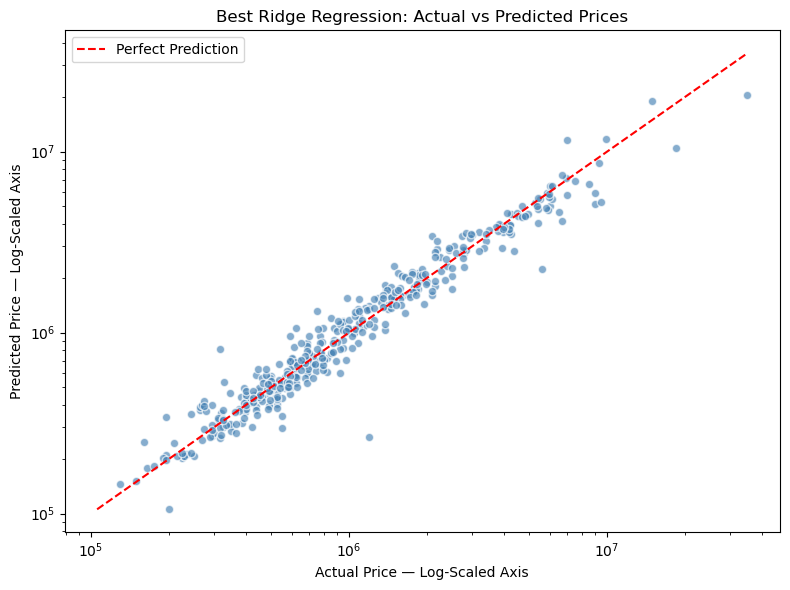

Figure saved to: ..\results\figures\ridge_actual_vs_predicted.png


In [35]:
minimum_price = min(
    y_test.min(),
    best_price_predictions.min()
)

maximum_price = max(
    y_test.max(),
    best_price_predictions.max()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_price_predictions,
    alpha=0.65,
    color="steelblue",
    edgecolor="white"
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Price — Log-Scaled Axis")
plt.ylabel("Predicted Price — Log-Scaled Axis")
plt.title("Best Ridge Regression: Actual vs Predicted Prices")
plt.legend()
plt.tight_layout()

actual_predicted_figure_path = (
    figures_path / "ridge_actual_vs_predicted.png"
)

plt.savefig(
    actual_predicted_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", actual_predicted_figure_path)

### Actual vs Predicted Price Observations

- Most test observations lie close to the perfect-prediction line, indicating a strong agreement between actual and predicted prices.
- Predictions are particularly well aligned for low- and medium-priced vehicles.
- The points become more dispersed for expensive vehicles, indicating larger prediction errors at the upper end of the Price range.
- Several of the highest-priced vehicles fall below the reference line, showing underprediction.
- A few high-priced vehicles are also overpredicted.
- The logarithmic axes make performance across different Price levels easier to inspect.
- The overall pattern is consistent with the final test R² of `0.8571`.

## 18. Analyze Model Residuals

Residuals represent the difference between actual and predicted values:

**Residual = Actual Price − Predicted Price**

A positive residual indicates underprediction, while a negative residual indicates overprediction.

Residuals will be examined on both the original Price scale and the log-transformed scale. A well-behaved regression model should produce residuals that are centered near zero without a strong systematic pattern.

The original-scale analysis reflects practical monetary errors, while the log-scale analysis matches the target used during model training.

In [36]:
price_residuals = (
    y_test.to_numpy()
    - best_price_predictions
)

log_residuals = (
    y_test_log.to_numpy()
    - best_log_predictions
)

print("Original Price Residuals")
print("Mean:", round(price_residuals.mean(), 2))
print("Median:", round(np.median(price_residuals), 2))
print("Standard deviation:", round(price_residuals.std(ddof=1), 2))
print("Positive residuals:", (price_residuals > 0).sum())
print("Negative residuals:", (price_residuals < 0).sum())

print("\nLog-Scale Residuals")
print("Mean:", round(log_residuals.mean(), 4))
print("Median:", round(np.median(log_residuals), 4))
print("Standard deviation:", round(log_residuals.std(ddof=1), 4))

Original Price Residuals
Mean: 76625.85
Median: -1600.35
Standard deviation: 997467.41
Positive residuals: 204
Negative residuals: 208

Log-Scale Residuals
Mean: -0.0007
Median: -0.0019
Standard deviation: 0.2125


### Residual Summary Observations

- The original-scale mean residual is positive at `76,625.85`, indicating net underprediction in monetary terms.
- However, the median residual is close to zero at `−1,600.35`.
- The large difference between the mean and median suggests that a small number of expensive vehicles with large positive residuals increased the mean.
- Positive and negative residual counts are nearly balanced at 204 and 208, respectively.
- The original-scale residual standard deviation is high at `997,467.41`, reflecting the influence of large Price errors.
- Log-scale residuals are centered very close to zero, with a mean of `−0.0007` and a median of `−0.0019`.
- This indicates that the Ridge model is approximately unbiased on the scale used during training.

### 18.1 Plot Residuals Against Predicted Values

Residuals will be plotted against predicted values on both the original Price scale and the log-transformed scale.

The horizontal zero line represents predictions with no error. A random and approximately even spread around zero is desirable.

A funnel-shaped pattern indicates changing error variance, while curves or clusters may indicate model misspecification, influential observations, or unmodeled feature relationships.



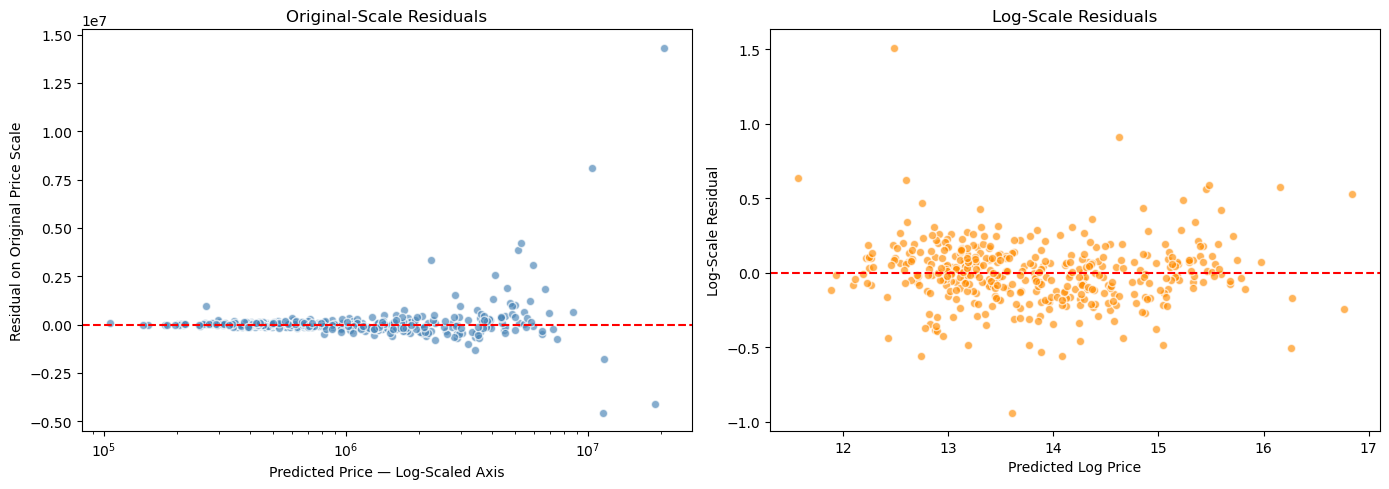

Figure saved to: ..\results\figures\ridge_residuals_vs_predicted.png


In [37]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].scatter(
    best_price_predictions,
    price_residuals,
    alpha=0.65,
    color="steelblue",
    edgecolor="white"
)

axes[0].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xscale("log")
axes[0].set_xlabel("Predicted Price — Log-Scaled Axis")
axes[0].set_ylabel("Residual on Original Price Scale")
axes[0].set_title("Original-Scale Residuals")

axes[1].scatter(
    best_log_predictions,
    log_residuals,
    alpha=0.65,
    color="darkorange",
    edgecolor="white"
)

axes[1].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[1].set_xlabel("Predicted Log Price")
axes[1].set_ylabel("Log-Scale Residual")
axes[1].set_title("Log-Scale Residuals")

plt.tight_layout()

residual_figure_path = (
    figures_path / "ridge_residuals_vs_predicted.png"
)

plt.savefig(
    residual_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", residual_figure_path)

### Residual Plot Observations

- Original-scale residual spread increases substantially for higher predicted prices.
- This funnel-shaped pattern indicates non-constant error variance on the original Price scale.
- Several expensive vehicles have very large positive residuals, confirming strong underprediction for some high-value observations.
- Large negative residuals also occur among expensive vehicles, showing occasional overprediction.
- Log-scale residuals are more evenly distributed around zero and have a more consistent spread.
- However, a few large log-scale outliers remain.
- A mild pattern across predicted Log Price suggests that some nonlinear relationships, rare vehicle characteristics, or omitted information may still be unexplained.
- Log transformation improved residual behavior but did not eliminate all model limitations.

### 18.2 Inspect the Log Residual Distribution and Q-Q Plot

The distribution of log-scale residuals will be examined using a histogram with a density curve and a normal Q-Q plot.

A symmetric histogram centered near zero indicates balanced errors. In the Q-Q plot, points close to the reference line indicate approximate normality.

Large deviations from the line, especially in the tails, indicate outliers or non-normal residual behavior.

Residual normality is more important for statistical inference than for predictive performance, but it remains a useful diagnostic.

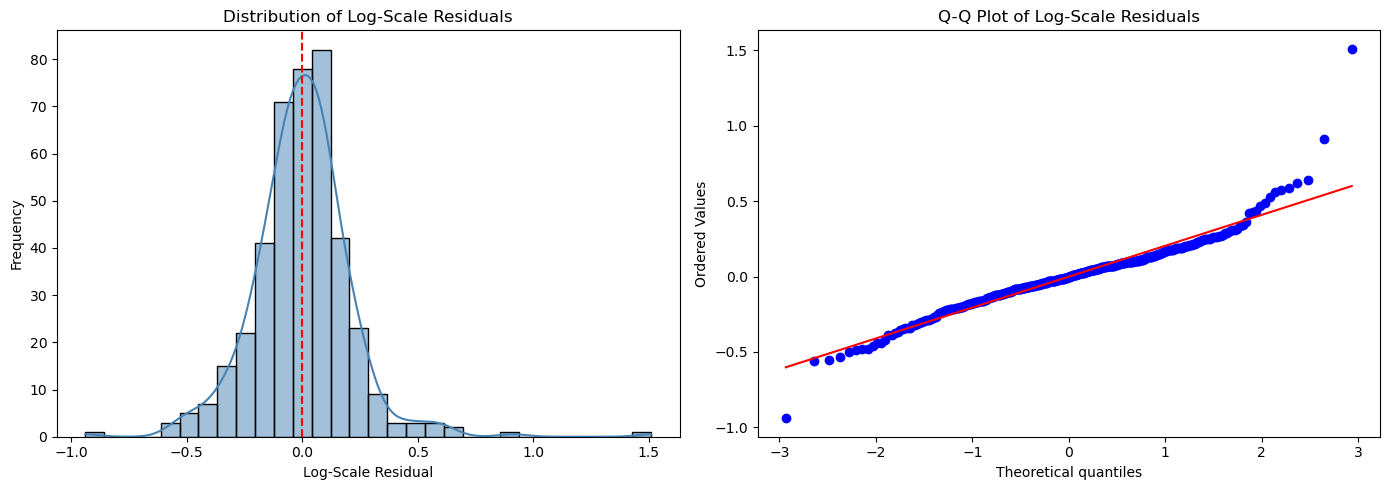

Figure saved to: ..\results\figures\ridge_log_residual_diagnostics.png


In [38]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    log_residuals,
    bins=30,
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xlabel("Log-Scale Residual")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Log-Scale Residuals")

stats.probplot(
    log_residuals,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Q-Q Plot of Log-Scale Residuals")

plt.tight_layout()

residual_diagnostics_path = (
    figures_path / "ridge_log_residual_diagnostics.png"
)

plt.savefig(
    residual_diagnostics_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", residual_diagnostics_path)

### Log Residual Distribution Observations

- The histogram is centered close to zero and has an approximately bell-shaped central region.
- Most residuals fall within a relatively narrow range, indicating reasonable performance for the majority of test observations.
- The distribution has heavy tails and a longer positive tail.
- Positive extreme residuals represent large underpredictions, while the negative extreme represents a large overprediction.
- In the Q-Q plot, the central observations follow the reference line reasonably well.
- Both tails deviate from the line, with stronger deviation in the upper tail.
- Therefore, log-scale residuals are approximately normal in the center but not normally distributed in the tails.
- This limits strict statistical inference but does not invalidate the model's predictive evaluation.

## 19. Research Interpretation

Five-fold cross-validation selected `alpha=0.5` with a mean validation Log RMSE of `0.2752`, indicating that mild regularization was most suitable for this dataset.

The final Ridge model achieved an MAE of `301,182.74`, an RMSE of `999,198.60`, and an R² of `0.8571`. It produced the lowest MAE among the compared models, while Basic Ridge achieved the best RMSE and R². Therefore, Ridge did not provide a clear predictive advantage across every metric.

The strongest evidence in favor of Ridge concerns coefficient behavior:

- the coefficient L2 norm decreased by `15.17%`;
- 115 of 160 coefficients moved closer to zero;
- mean coefficient variability decreased by `37.70%`;
- Ridge improved coefficient stability for 140 of 160 features.

High VIF values remained present because Ridge does not remove predictor correlations. However, the shrinkage and stability results show that it reduced the effect of multicollinearity on coefficient estimation.

Residual diagnostics showed strong overall prediction alignment, but expensive and unusual vehicles produced larger errors. Log transformation improved residual behavior, although heavy-tail deviations and outliers remained.

Overall, Ridge provided a more stable coefficient solution with similar predictive performance to Log-Target Linear Regression.

## 20. Industry Interpretation

The Ridge pipeline provides a reproducible workflow because feature engineering, missing-value handling, scaling, encoding, and prediction follow consistent rules.

The model produced no negative Price predictions and achieved an average absolute error of approximately `301,183`. However, whether this error is acceptable depends on the pricing range and business requirements.

Ridge is useful as an interpretable and stable baseline for:

- preliminary used-car valuation;
- dealer pricing support;
- listing-quality checks;
- comparison with more complex nonlinear models.

Important operational considerations include:

- unseen categories are handled safely but may reduce accuracy;
- expensive and rare vehicles require additional review because their errors are larger;
- market prices can change over time, so performance and data drift must be monitored;
- periodic retraining is required when new vehicle and transaction data become available;
- predictions should support human decisions rather than automatically determine final prices.

Before production use, Ridge should be compared with tree-based and boosting models while retaining this pipeline as a transparent benchmark.

## 21. Limitations

This Ridge Regression analysis has several limitations:

- The dataset contains only 2,059 observations, which may not represent the complete used-car market.
- The Kaggle dataset may contain collection bias, outdated listings, or incomplete vehicle information.
- Ridge assumes additive linear relationships and may not capture complex nonlinear interactions.
- High-cardinality `Model` and other rare categories remain difficult to estimate reliably.
- Unseen test categories are encoded as all zeros, which prevents failure but may reduce accuracy.
- `Vehicle_Age` is calculated using the fixed reference year `2022`; this must be updated for future data.
- Converting log predictions with `expm1` does not apply a retransformation-bias correction and may contribute to underprediction on the original Price scale.
- Large errors remain for expensive and unusual vehicles.
- Residuals show non-constant variance on the original scale and heavy-tail deviations on the log scale.
- The coefficient-stability diagnostic used five training subsets and does not provide formal confidence intervals.
- Results are based on one fixed train-test split, so external validation on a new dataset is still required.
- Ridge improves coefficient stability but does not remove multicollinearity or reduce VIF values.

## 22. Save Ridge Regression Results

The important Ridge Regression outputs will be saved as CSV files in the `results/` directory.

The saved files will include:

- alpha cross-validation results;
- model-performance comparison;
- final Ridge coefficients;
- Linear-versus-Ridge coefficient shrinkage;
- coefficient-stability results;
- high-VIF numerical coefficient comparison.

All filenames are Ridge-specific, so previous Linear Regression results will not be overwritten.

In [39]:
results_path = Path("../results")

results_path.mkdir(
    parents=True,
    exist_ok=True
)

ridge_cv_results.to_csv(
    results_path / "ridge_alpha_cv_results.csv",
    index=False
)

ridge_model_comparison.to_csv(
    results_path / "ridge_model_comparison.csv",
    index=False
)

ridge_coefficient_table.to_csv(
    results_path / "ridge_regression_coefficients.csv",
    index=False
)

coefficient_shrinkage_table.to_csv(
    results_path / "linear_vs_ridge_coefficients.csv",
    index=False
)

coefficient_stability_table.to_csv(
    results_path / "ridge_coefficient_stability.csv",
    index=False
)

high_vif_coefficient_comparison.to_csv(
    results_path / "ridge_vif_coefficient_comparison.csv",
    index=False
)

print("Ridge result files saved successfully.")
print("1. ridge_alpha_cv_results.csv")
print("2. ridge_model_comparison.csv")
print("3. ridge_regression_coefficients.csv")
print("4. linear_vs_ridge_coefficients.csv")
print("5. ridge_coefficient_stability.csv")
print("6. ridge_vif_coefficient_comparison.csv")

Ridge result files saved successfully.
1. ridge_alpha_cv_results.csv
2. ridge_model_comparison.csv
3. ridge_regression_coefficients.csv
4. linear_vs_ridge_coefficients.csv
5. ridge_coefficient_stability.csv
6. ridge_vif_coefficient_comparison.csv


## 23. Final Conclusion

This notebook developed a complete Ridge Regression workflow for used-car price prediction using leakage-safe preprocessing and a log-transformed target.

Five-fold cross-validation selected `alpha=0.5`. The final Ridge model achieved:

- **MAE:** `301,182.74`
- **RMSE:** `999,198.60`
- **R²:** `0.8571`
- **Negative predictions:** `0`

Ridge produced the lowest MAE among the compared models, while Basic Ridge achieved the best RMSE and R². Therefore, Ridge did not outperform Log-Target Linear Regression across every predictive metric.

The main benefit of Ridge was improved coefficient behavior:

- coefficient L2 norm decreased by `15.17%`;
- 115 of 160 coefficients moved closer to zero;
- mean coefficient variability decreased by `37.70%`;
- 140 of 160 features had more stable coefficients.

Residual analysis showed strong overall prediction performance but larger errors for expensive and unusual vehicles. Log transformation improved residual behavior, although outliers and heavy-tail deviations remained.

Overall, Ridge Regression provided similar predictive performance to Log-Target Linear Regression while producing a smaller and more stable coefficient solution under multicollinearity. It is therefore a useful interpretable benchmark for this used-car pricing project.